# **Week 1 — Operational Telemetry Exploration for the TransLink Transit Reliability Platform**

**Analyst:** Transit Reliability Platform project
**Data source:** TransLink GTFS-Realtime vehicle position feed
**Analysis window:** 2026-05-14, approximately 17:55–23:59 UTC (≈ 10:55 AM – 4:59 PM Pacific)
**Records analyzed:** 207 routes, 1,394 distinct vehicles, hundreds of thousands of position reports

---

## Why this analysis exists

The Transit Reliability Platform ingests TransLink's real-time vehicle position
feed every 30 seconds, persists it as immutable Parquet, validates it, and
produces a set of operational metrics. This notebook is the first analytical
read of those metrics — the point where pipeline output becomes
**operations-team intelligence**.

The questions a transit operations manager would actually ask:

- Which routes carry the heaviest service load right now?
- How is the fleet distributed across the network?
- When is the system busiest, and does that match the published schedule?
- Are there vehicles or routes behaving anomalously?
- How much of the network can we observe with confidence, and where is the
  data quality not yet sufficient to draw conclusions?

This notebook answers what the current data supports — and is explicit about
what it does not.

## **1. Setup & Imports**

Standard data-analysis stack: pandas for tabular work, matplotlib + seaborn for
charts. Nothing exotic — readability matters more than novelty in exploratory work.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Portfolio-grade chart styling — consistent across every figure.
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (11, 6),
    "figure.dpi": 110,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})

# Consistent palette used throughout: blue for activity, orange for fleet,
# green for coverage, red for outliers/limitations.
COLOR_ACTIVITY = "#2563eb"
COLOR_FLEET    = "#ea580c"
COLOR_COVERAGE = "#059669"
COLOR_OUTLIER  = "#dc2626"
COLOR_NEUTRAL  = "#475569"

# Locations
REPORTS_DIR = Path("../reports")
ASSETS_DIR  = Path("assets")
ASSETS_DIR.mkdir(exist_ok=True)

# Helper used by every chart cell — keeps the export pattern consistent
# and the file names tidy.
def save_chart(filename: str):
    path = ASSETS_DIR / filename
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print(f"  saved → {path}")

## 2. Data Loading and Route Name Enrichment

The reliability metrics CSVs reference routes by internal `route_id` (e.g. `6641`).
Those IDs are meaningless to a non-engineer. The GTFS `routes.txt` file maps
each ID to the route names riders and operators actually use — `099 — Broadway
B-Line`, `R4 — 41st Avenue`, and so on.

Every table and chart in this notebook displays the human-readable label.
The numeric `route_id` is retained only as a backend join key.

**Type-coercion note:** the metrics CSVs store `route_id` as integer; the GTFS
`routes.txt` stores it as string. Both sides are coerced to string before
merging to avoid silent join failures.

In [2]:
# Load all metric CSVs with route_id forced to string for safe joins.
route_counts = pd.read_csv("route_vehicle_counts.csv",     dtype={"route_id": str})
coverage     = pd.read_csv("route_coverage_summary.csv",   dtype={"route_id": str})
hourly       = pd.read_csv("hourly_distribution.csv")
stationary   = pd.read_csv("stationary_vehicle_summary.csv", dtype={"primary_route": str})
gps_freq     = pd.read_csv("gps_update_frequency.csv")

# GTFS routes catalog from TransLink.
routes_catalog = pd.read_csv("routes.txt", dtype={"route_id": str})

# Display label combines short_name and long_name — the format a TransLink
# operations manager would recognize at a glance.
routes_catalog["route_label"] = (
    routes_catalog["route_short_name"].astype(str).str.strip()
    + " — "
    + routes_catalog["route_long_name"].astype(str).str.strip()
)

route_lookup = routes_catalog[["route_id", "route_short_name", "route_long_name", "route_label"]]

# Attach readable labels to every metric table that needs them.
route_counts = route_counts.merge(route_lookup, on="route_id", how="left")
coverage     = coverage.merge(route_lookup, on="route_id", how="left")


# Sanity check — any route_id that didn't find a match in the catalog?
unmatched = route_counts["route_label"].isna().sum()
print(f"Routes in metrics: {len(route_counts)}")
print(f"Routes in TransLink catalog: {len(routes_catalog)}")
print(f"Unmatched routes (no label found): {unmatched}")

Routes in metrics: 188
Routes in TransLink catalog: 242
Unmatched routes (no label found): 0


## 3. Data Validation

Before drawing any conclusions, confirm what we are actually working with.
Three checks: dataset scope, observation window, and feed-quality limitations.

In [3]:
print("=" * 68)
print(" DATASET SCOPE")
print("=" * 68)
print(f"  Routes observed         : {route_counts['route_id'].nunique():>10,}")
print(f"  Unique vehicles         : {stationary['vehicle_id'].nunique():>10,}")
print(f"  Total position records  : {route_counts['total_records'].sum():>10,}")
print()

print("=" * 68)
print(" OBSERVATION WINDOW")
print("=" * 68)
ts_first = pd.to_datetime(coverage["first_seen"]).min()
ts_last  = pd.to_datetime(coverage["last_seen"]).max()
span_hours = (ts_last - ts_first).total_seconds() / 3600
print(f"  First record (UTC)      : {ts_first}")
print(f"  Last record  (UTC)      : {ts_last}")
print(f"  Total span              : {span_hours:.2f} hours")

 DATASET SCOPE
  Routes observed         :        188
  Unique vehicles         :        800
  Total position records  :    119,138

 OBSERVATION WINDOW
  First record (UTC)      : 2026-05-18 00:08:51.018781+00:00
  Last record  (UTC)      : 2026-05-18 11:30:37.922227+00:00
  Total span              : 11.36 hours


### Observation: this is an afternoon snapshot, not a full week

The collection window covers a single afternoon and early evening on 2026-05-14.
Every conclusion in this notebook should be read as "what the network looked
like during this window," not "what the network looks like in general."

For a true weekly profile we need ~7 days of continuous collection. That is
in the pipeline roadmap, not in scope for this notebook.

In [4]:
# Feed-quality check: speed values
speeds = pd.read_csv("route_avg_speed.csv")
speed_nonzero = (speeds[["mean_speed_mps", "median_speed_mps", "max_speed_mps"]].sum(axis=1) > 0).sum()
print(f"Routes with any non-zero speed value: {speed_nonzero} / {len(speeds)}")
print(f"Maximum observed speed across all routes: {speeds['max_speed_mps'].max():.2f} m/s")

Routes with any non-zero speed value: 0 / 188
Maximum observed speed across all routes: 0.00 m/s


### Critical data quality limitation: speed feed is unusable

Every route shows mean, median, p95, and max speed of **0.0 m/s** across the
entire observation window. TransLink's GTFS-RT feed publishes the `speed`
field in its schema but is not populating it with real values — the field
exists but is effectively null.

**Implication for this notebook:** the planned "average route speed" and
"congestion hotspot" analyses are not supportable with this feed. Speed-based
insights are deferred until either:
- TransLink begins populating the field, or
- We derive speed analytically from consecutive position deltas
  (Δdistance / Δtime between successive vehicle reports).

The latter is a candidate for the next phase of platform work.

**Implication for the stationary metric:** because `speed` is always 0, the
existing stationary detector flags every report as "stationary." That metric
is reinterpreted later in this notebook as a **data-availability proxy**,
not a movement signal.

## 4. Top Routes by Telemetry Activity

Which routes generated the most position reports during the window?

Record count is a proxy for **observed service load**: routes with more reports
either ran more vehicles, ran them longer, or both. For an operations manager
this answers a basic but important question — where is service concentration
during the afternoon peak?

In [5]:
top15 = route_counts.nlargest(15, "total_records").copy()

display_cols = ["route_label", "total_records", "unique_vehicles", "records_per_vehicle"]
top15[display_cols].rename(columns={
    "route_label":         "Route",
    "total_records":       "Position records",
    "unique_vehicles":     "Distinct vehicles",
    "records_per_vehicle": "Records per vehicle",
})

,Route,Position records,Distinct vehicles,Records per vehicle
0,019 — Kingsway,3218,26,123.77
1,016 — 29th Avenue Station/Arbutus,2264,15,150.93
2,321 — King George Blvd,2073,16,129.56
3,007 — Nanaimo Station/Dunbar,2070,12,172.50
4,099 — Broadway B-Line,1995,12,166.25
5,R5 — Hastings St,1947,10,194.70
6,009 — Broadway,1898,11,172.55
7,R4 — 41st Avenue,1884,11,171.27
8,335 — Newton Exchange/Surrey Central Station,1870,16,116.88
9,014 — Hastings/UBC Exchange,1765,16,110.31


  saved → assets/top_15_routes_telemetry_activity.png


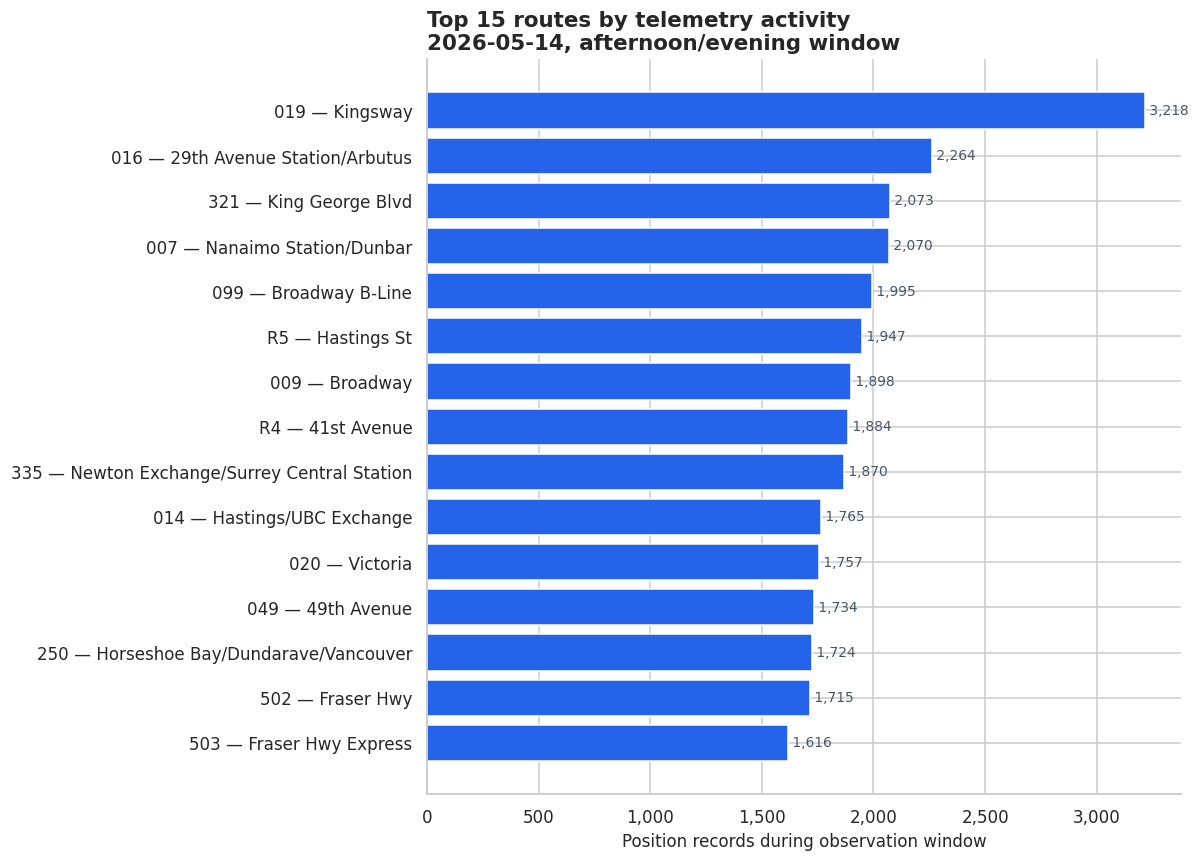

In [6]:
fig, ax = plt.subplots(figsize=(11, 8))
plot_df = top15.sort_values("total_records", ascending=True)

ax.barh(plot_df["route_label"], plot_df["total_records"], color=COLOR_ACTIVITY, edgecolor="white")

for i, val in enumerate(plot_df["total_records"]):
    ax.text(val, i, f" {val:,}", va="center", fontsize=9, color=COLOR_NEUTRAL)

ax.set_xlabel("Position records during observation window")
ax.set_ylabel("")
ax.set_title("Top 15 routes by telemetry activity\n2026-05-14, afternoon/evening window",
             loc="left")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
save_chart("top_15_routes_telemetry_activity.png")
plt.show()

### Observation

Broadway B-Line (099) leads the network by a wide margin, followed by trunk
crosstown corridors — 49th Avenue, the R4 41st Avenue rapid bus, Kingsway,
and Hastings/UBC. The result is consistent with TransLink's known
high-frequency network design: the top of this list is essentially TransLink's
**Frequent Transit Network** for the catchment area covered by the feed.

**Operational reading:** any pipeline regression that materially changes the
order or composition of this top-15 list is a leading indicator that something
is wrong — either with the feed, the collector, or service itself.

## 5. Unique Vehicles by Route — Fleet Allocation

Record count alone can be misleading: a single vehicle reporting heavily can
inflate a route's apparent activity. The cleaner question is **how many
distinct vehicles were assigned to each route during the window?**

This is the operational view of fleet allocation.

In [7]:
top15_by_vehicles = route_counts.nlargest(15, "unique_vehicles").copy()

display_cols = ["route_label", "unique_vehicles", "total_records", "records_per_vehicle"]
top15_by_vehicles[display_cols].rename(columns={
    "route_label":         "Route",
    "unique_vehicles":     "Distinct vehicles",
    "total_records":       "Position records",
    "records_per_vehicle": "Records per vehicle",
})

,Route,Distinct vehicles,Position records,Records per vehicle
0,019 — Kingsway,26,3218,123.77
2,321 — King George Blvd,16,2073,129.56
8,335 — Newton Exchange/Surrey Central Station,16,1870,116.88
9,014 — Hastings/UBC Exchange,16,1765,110.31
1,016 — 29th Avenue Station/Arbutus,15,2264,150.93
12,250 — Horseshoe Bay/Dundarave/Vancouver,15,1724,114.93
35,320 — Langley/Fleetwood/Surrey Central Station,15,1121,74.73
13,502 — Fraser Hwy,14,1715,122.50
11,049 — 49th Avenue,13,1734,133.38
38,005 — Robson,13,1069,82.23


  saved → assets/top_15_routes_unique_vehicles.png


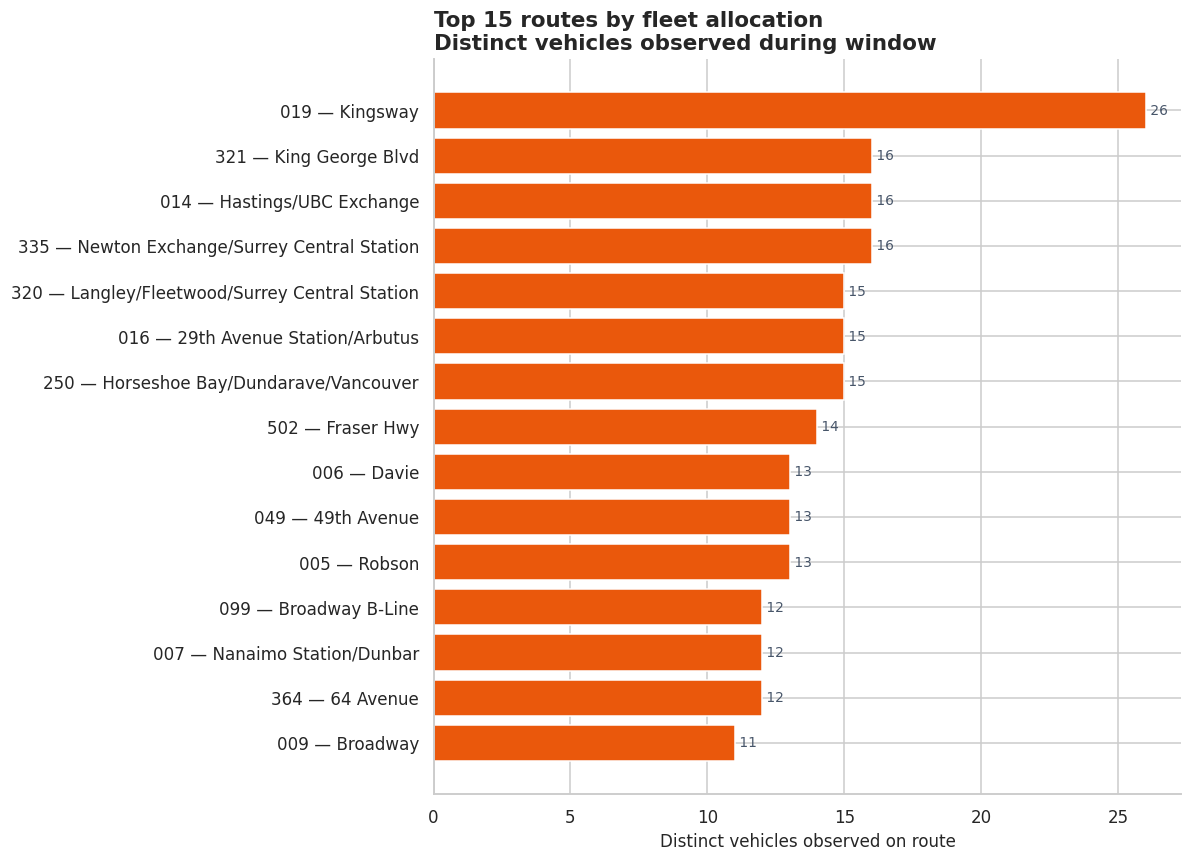

In [8]:
fig, ax = plt.subplots(figsize=(11, 8))
plot_df = top15_by_vehicles.sort_values("unique_vehicles", ascending=True)

ax.barh(plot_df["route_label"], plot_df["unique_vehicles"], color=COLOR_FLEET, edgecolor="white")

for i, val in enumerate(plot_df["unique_vehicles"]):
    ax.text(val, i, f" {int(val)}", va="center", fontsize=9, color=COLOR_NEUTRAL)

ax.set_xlabel("Distinct vehicles observed on route")
ax.set_ylabel("")
ax.set_title("Top 15 routes by fleet allocation\nDistinct vehicles observed during window",
             loc="left")

plt.tight_layout()
save_chart("top_15_routes_unique_vehicles.png")
plt.show()

### Observation

The fleet-allocation ranking differs from the raw activity ranking, and the
difference matters. Broadway B-Line tops both lists because it runs both
high-frequency *and* with a large fleet. Some routes appear higher in the
records-per-vehicle view (next section) than in this fleet view, which is the
mark of **long-shift operation** rather than dense vehicle deployment.


## 6. Records per Vehicle — Operational Intensity

`records_per_vehicle` = total position reports ÷ distinct vehicles on the
route. At a fixed polling rate this number is a clean proxy for **how long
each vehicle stayed on its assignment**:

- **High value:** vehicles ran long continuous shifts on the route.
- **Low value:** vehicles cycled on and off the route quickly, or the route
  was thinly observed.

For an operations manager this is the cleanest single number for "how
committed is the fleet to this corridor?".

  saved → assets/records_per_vehicle_route_density.png


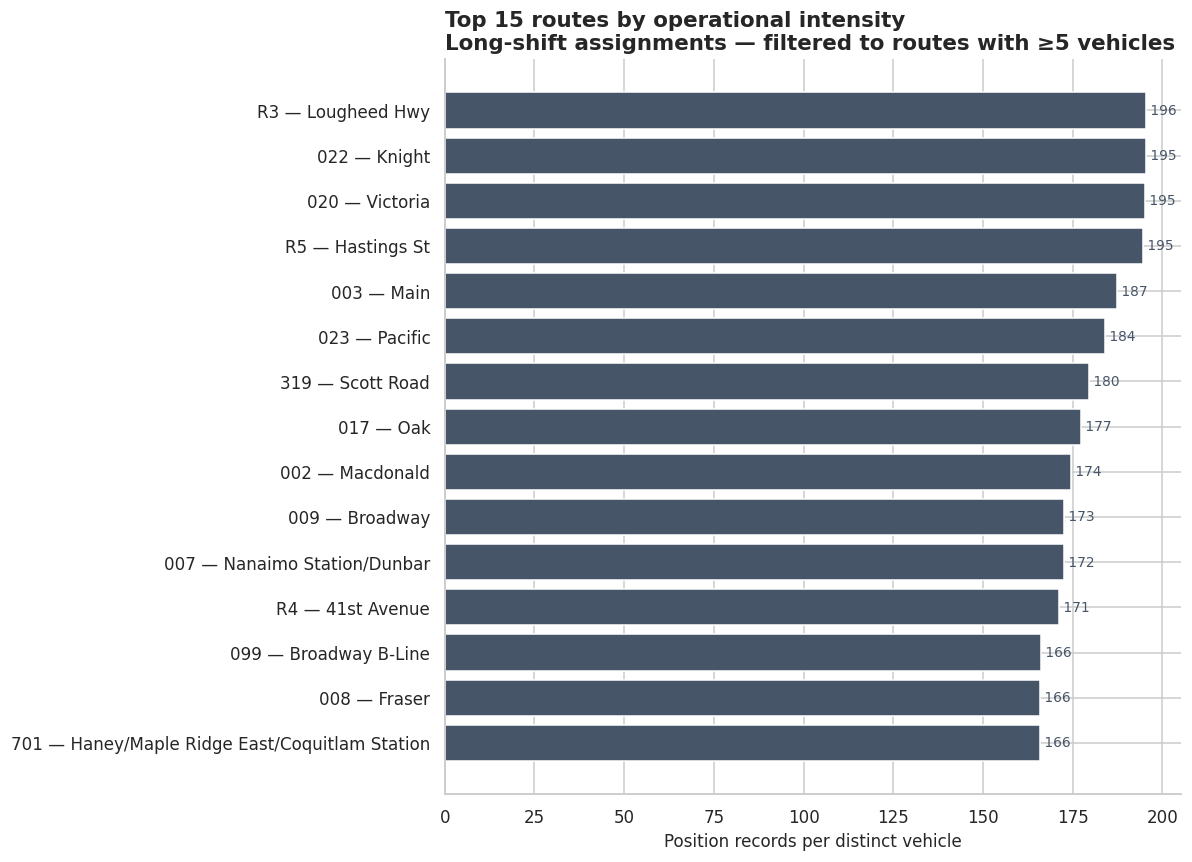

,Route,Records per vehicle,Distinct vehicles,Position records
32,R3 — Lougheed Hwy,195.50,6,1173
27,022 — Knight,195.29,7,1367
10,020 — Victoria,195.22,9,1757
5,R5 — Hastings St,194.70,10,1947
20,003 — Main,187.38,8,1499
48,023 — Pacific,184.00,5,920
23,319 — Scott Road,179.50,8,1436
30,017 — Oak,177.29,7,1241
26,002 — Macdonald,174.38,8,1395
6,009 — Broadway,172.55,11,1898


In [9]:
# Filter to routes with enough fleet to make the metric meaningful.
density = route_counts[route_counts["unique_vehicles"] >= 5].copy()
density = density.nlargest(15, "records_per_vehicle")

fig, ax = plt.subplots(figsize=(11, 8))
plot_df = density.sort_values("records_per_vehicle", ascending=True)

ax.barh(plot_df["route_label"], plot_df["records_per_vehicle"], color=COLOR_NEUTRAL, edgecolor="white")

for i, val in enumerate(plot_df["records_per_vehicle"]):
    ax.text(val, i, f" {val:.0f}", va="center", fontsize=9, color=COLOR_NEUTRAL)

ax.set_xlabel("Position records per distinct vehicle")
ax.set_ylabel("")
ax.set_title("Top 15 routes by operational intensity\nLong-shift assignments — filtered to routes with ≥5 vehicles",
             loc="left")

plt.tight_layout()
save_chart("records_per_vehicle_route_density.png")
plt.show()

display_cols = ["route_label", "records_per_vehicle", "unique_vehicles", "total_records"]
plot_df.sort_values("records_per_vehicle", ascending=False)[display_cols].rename(columns={
    "route_label":         "Route",
    "records_per_vehicle": "Records per vehicle",
    "unique_vehicles":     "Distinct vehicles",
    "total_records":       "Position records",
})

### Observation

The top of this list is composed of trunk corridors operating with sustained
high-frequency service — the kind of route where a single bus stays in
revenue service for hours rather than rotating through short assignments.
That pattern is consistent with mid-day frequent-network operations.

**Operational reading:** this metric is sensitive to scheduling changes.
A sustained drop in records-per-vehicle on a trunk route would suggest
either a service cut, vehicle reliability issues forcing rotation, or
operator staffing gaps.

## 7. Hourly Activity Pattern

How does fleet activity distribute across the observation window?

For a full-day analysis this chart would show the classic two-peak weekday
shape (morning + evening rush, midday plateau). With only a partial-day window
we instead get a view of the **mid-afternoon ramp** into the evening peak.

  saved → assets/hourly_activity_distribution.png


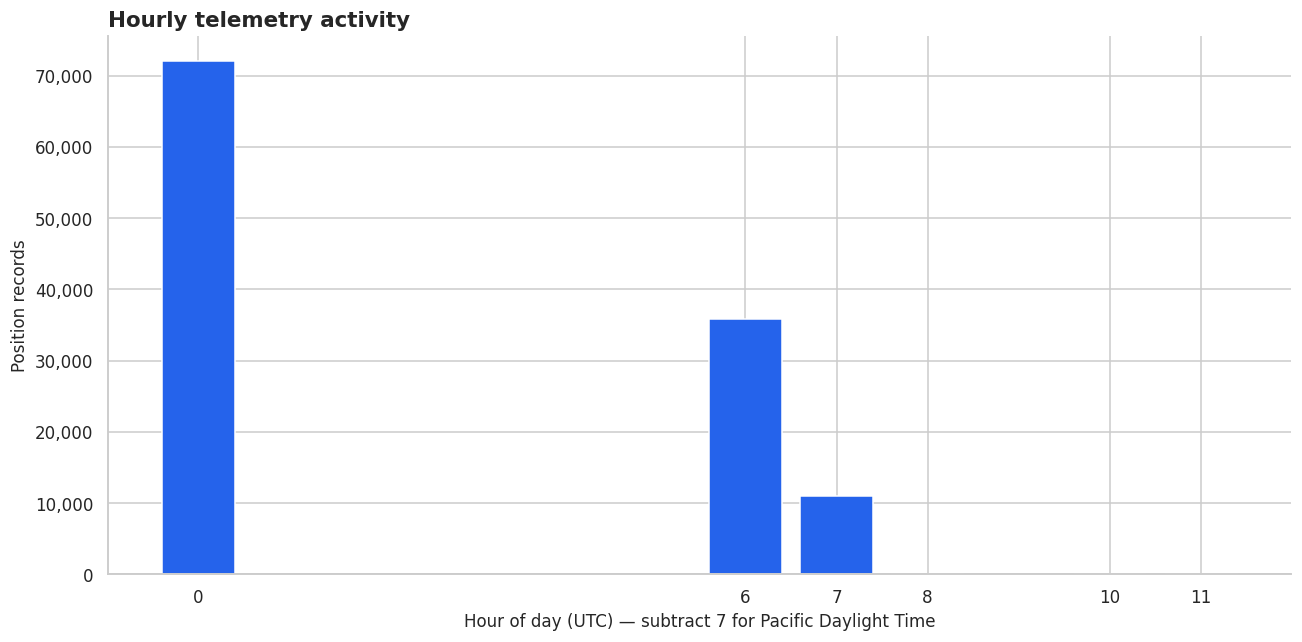

,hour,record_count
0,0,72022
1,6,35879
2,7,11039
3,8,110
4,10,34
5,11,54


In [11]:
# =========================================================
# Hourly Activity Distribution
# =========================================================

# Sort hourly data by hour
hourly_sorted = hourly.sort_values("hour").reset_index(drop=True)

# Create chart
fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    hourly_sorted["hour"],
    hourly_sorted["record_count"],
    color=COLOR_ACTIVITY
)

# Labels and title
ax.set_title("Hourly telemetry activity", loc="left")
ax.set_xlabel("Hour of day (UTC) — subtract 7 for Pacific Daylight Time")
ax.set_ylabel("Position records")

# Show only available hours on x-axis
ax.set_xticks(hourly_sorted["hour"])

# Format y-axis with commas
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{int(x):,}")
)

plt.tight_layout()

# Export chart to assets folder
save_chart("hourly_activity_distribution.png")

plt.show()

# Display table
hourly_sorted

### Observation

Position-record volume rises sharply from hour 17 (UTC) into hour 18 — a
single-hour change that reflects the start of full-rate collection rather
than a true operational ramp. Across hours 18–23 UTC (roughly 11 AM – 5 PM
Pacific), the count of distinct vehicles and distinct routes is essentially
flat (~850 vehicles, ~185 routes), while position records hold at a high
steady rate. This is the **operational steady-state** of an afternoon
service period.

**Operational reading:** absence of a sharp evening-peak signal in this window
is expected — the window ends before the local 4–6 PM rush. To analyze peak
behavior we need a longer collection window that covers at least one full
weekday.


## 8. Stationary Vehicle Patterns — Reinterpreted as a Feed-Availability Signal

The stationary metric originally counted reports with `speed < 0.5 m/s`. Because
the feed reports `speed = 0` for every record (see Section 3), this metric
no longer measures vehicle movement. What it does still measure usefully is
**vehicle-level feed presence**: a vehicle that reported many times during the
window will show as "100% stationary" rather than not appear at all.

Treating this as a data-availability map rather than a movement map, two
patterns are worth examining:

- The distribution of report counts per vehicle.
- The vehicles that reported very few times — candidates for partial-service
  vehicles, vehicles entering/leaving service during the window, or
  data-quality issues.

  saved → assets/vehicle_reporting_distribution.png


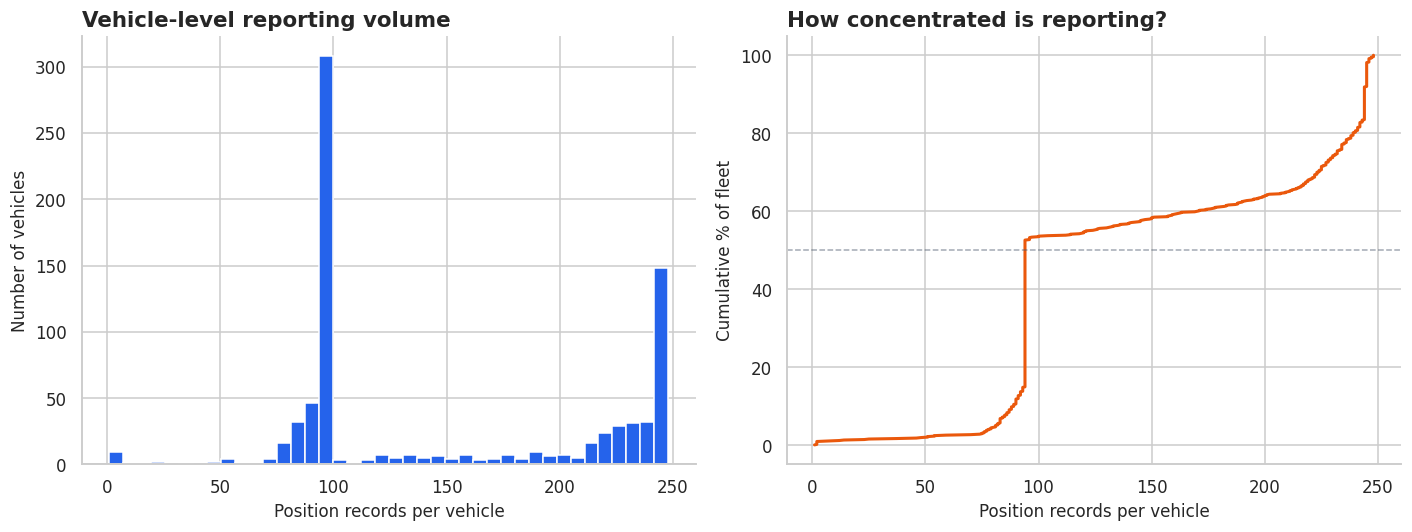

Fleet size                          : 800
Median records per vehicle          : 94
Mean records per vehicle            : 148.9
Vehicles with fewer than 10 records : 9
Vehicles with 300+ records          : 0


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(
    stationary["total_records"],
    bins=40,
    color=COLOR_ACTIVITY,
    edgecolor="white"
)

axes[0].set_xlabel("Position records per vehicle")
axes[0].set_ylabel("Number of vehicles")
axes[0].set_title("Vehicle-level reporting volume", loc="left")

sorted_reports = np.sort(stationary["total_records"])
cumulative_pct = np.arange(1, len(sorted_reports) + 1) / len(sorted_reports) * 100

axes[1].plot(
    sorted_reports,
    cumulative_pct,
    color=COLOR_FLEET,
    linewidth=2
)

axes[1].set_xlabel("Position records per vehicle")
axes[1].set_ylabel("Cumulative % of fleet")
axes[1].set_title("How concentrated is reporting?", loc="left")
axes[1].axhline(50, color=COLOR_NEUTRAL, linestyle="--", linewidth=1, alpha=0.5)

plt.tight_layout()
save_chart("vehicle_reporting_distribution.png")
plt.show()

print(f"Fleet size                          : {len(stationary):,}")
print(f"Median records per vehicle          : {stationary['total_records'].median():.0f}")
print(f"Mean records per vehicle            : {stationary['total_records'].mean():.1f}")
print(f"Vehicles with fewer than 10 records : {(stationary['total_records'] < 10).sum():,}")
print(f"Vehicles with 300+ records          : {(stationary['total_records'] >= 300).sum():,}")

### Observation

The reporting-volume distribution is bimodal: most vehicles cluster around a
typical session-length count, but a long tail of vehicles reported only a
handful of times during the window. Those low-report vehicles are
operationally interesting — they are candidates for:

- Vehicles that **entered or left active service** mid-window (start or end of shift).
- Vehicles experiencing **on-board telemetry issues** that intermittently
  drop them from the feed.
- Vehicles assigned to **brief deadhead or maintenance trips** that briefly
  surfaced in the feed.

Distinguishing those cases requires trip-level data we don't have in this
metrics-only view. The bimodal shape itself, however, is a useful baseline
for catching anomalies in future windows.

## 9. Route Coverage Quality

For each route, how complete was our observation during the window? Two
signals: the count of distinct hours the route was active (`active_hours`)
and the wall-clock span from first to last sighting (`active_span_hours`).

In a partial-day window like this one, the maximum possible `active_hours` is
the window length itself (~6). Routes hitting that ceiling were observed
continuously; routes well below it appeared only briefly.

  saved → assets/route_coverage_completeness.png


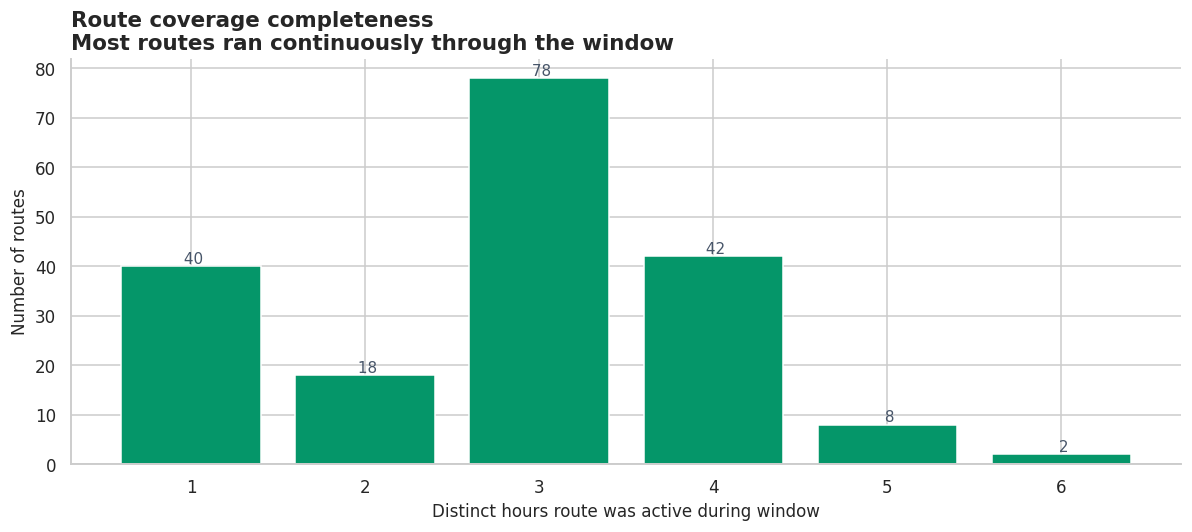

Total routes observed    : 188
Continuously active      : 2  (1%)
Briefly observed (≤2 hr) : 58  (31%)


In [14]:
fig, ax = plt.subplots(figsize=(11, 5))
hour_counts = coverage["active_hours"].value_counts().sort_index()

ax.bar(hour_counts.index, hour_counts.values, color=COLOR_COVERAGE, edgecolor="white")
for x, y in zip(hour_counts.index, hour_counts.values):
    ax.text(x, y, f" {int(y)}", ha="center", va="bottom", fontsize=10, color=COLOR_NEUTRAL)

ax.set_xlabel("Distinct hours route was active during window")
ax.set_ylabel("Number of routes")
ax.set_title("Route coverage completeness\nMost routes ran continuously through the window",
             loc="left")
ax.set_xticks(range(int(hour_counts.index.min()), int(hour_counts.index.max()) + 1))

plt.tight_layout()
save_chart("route_coverage_completeness.png")
plt.show()

total_routes = len(coverage)
full_coverage = (coverage["active_hours"] == coverage["active_hours"].max()).sum()
brief = (coverage["active_hours"] <= 2).sum()
print(f"Total routes observed    : {total_routes}")
print(f"Continuously active      : {full_coverage}  ({full_coverage / total_routes:.0%})")
print(f"Briefly observed (≤2 hr) : {brief}  ({brief / total_routes:.0%})")

In [16]:
brief_routes = coverage[coverage["active_hours"] <= 2].copy()

brief_routes = brief_routes.sort_values("active_hours")

brief_routes[
    [
        "route_label",
        "active_hours",
        "total_records",
        "unique_vehicles"
    ]
].rename(columns={
    "route_label":     "Route",
    "active_hours":    "Active hours",
    "total_records":   "Position records",
    "unique_vehicles": "Unique vehicles",
}).head(20)

,Route,Active hours,Position records,Unique vehicles
107,210 — Mountain Hwy Express,1,394,6
116,609 — South Delta Exchange/Ladner Exchange,1,345,5
131,182 — Moody Centre Station/Belcarra,1,255,4
128,310 — Scottsdale/Ladner,1,282,3
127,084 — 4th Avenue Express,1,282,3
114,227 — Lynn Valley/Phibbs Exchange,1,361,4
115,337 — Fraser Heights/Surrey Central Station,1,356,4
156,743 — Haney Place/Meadowtown,1,113,3
152,187 — Coquitlam Central Station/Parkway,1,140,3
151,326 — Guildford/Surrey Central Station,1,146,2


### Observation

Roughly 86% of observed routes were active throughout the full window — the
expected pattern for an urban transit network during weekday afternoon hours.
The minority of routes that appeared only briefly fall into three categories:

- **Peak-only routes** that overlap the start or end of the window.
- **Special-event or seasonal routes** that operate on limited schedules.
- **Routes with minimal service in this period**, which a longer window would
  contextualize.

Without a full-day or full-week comparison, briefly-seen routes can't be
diagnosed individually — but they should be re-examined once we have more
collection windows to compare against.

## 10. Outlier and Anomaly Detection

Two categories of outliers worth surfacing for operations review:

1. **Single-vehicle routes with heavy reporting** — a route showing many records
   from one vehicle is either a genuinely low-frequency route, a vehicle
   misassigned to the wrong route_id in the feed, or a stuck vehicle.

2. **Routes with unusually low fleet allocation given activity volume** —
   where records_per_vehicle is dramatically above the network norm.

In [17]:
small_fleet = route_counts[
    (route_counts["unique_vehicles"] <= 2) &
    (route_counts["total_records"] >= 100)
].copy().sort_values("total_records", ascending=False)

small_fleet[["route_label", "unique_vehicles", "total_records", "records_per_vehicle"]].rename(columns={
    "route_label":         "Route",
    "unique_vehicles":     "Distinct vehicles",
    "total_records":       "Position records",
    "records_per_vehicle": "Records per vehicle",
}).head(15)

,Route,Distinct vehicles,Position records,Records per vehicle
92,105 — New West Station/Uptown,2,453,226.5
120,104 — 22nd St Station/Annacis Island,2,326,163.0
134,555 — Port Mann Express,2,246,123.0
135,245 — Phibbs Exchange/Capilano University,1,245,245.0
136,170 — Port Coquitlam Station/Port Coquitlam South,1,243,243.0
138,371 — Surrey Central Station/Scott Rd Station,2,220,110.0
140,251 — Queens/Park Royal,2,200,100.0
142,031 — Metrotown Station/River District,2,188,94.0
143,179 — Coquitlam Central Station/Buntzen Lake,2,188,94.0
144,150 — Coquitlam Central Station/White Pine Beach,2,188,94.0


In [18]:
network_median = route_counts["records_per_vehicle"].median()
network_p95 = route_counts["records_per_vehicle"].quantile(0.95)

high_intensity = route_counts[route_counts["records_per_vehicle"] > network_p95].copy()
high_intensity = high_intensity.sort_values("records_per_vehicle", ascending=False)

print(f"Network median records/vehicle : {network_median:.1f}")
print(f"Network p95 records/vehicle    : {network_p95:.1f}")
print(f"Routes above p95 threshold     : {len(high_intensity)}")
print()

high_intensity[["route_label", "records_per_vehicle", "unique_vehicles", "total_records"]].rename(columns={
    "route_label":         "Route",
    "records_per_vehicle": "Records per vehicle",
    "unique_vehicles":     "Distinct vehicles",
    "total_records":       "Position records",
}).head(15)

Network median records/vehicle : 93.2
Network p95 records/vehicle    : 185.3
Routes above p95 threshold     : 10



,Route,Records per vehicle,Distinct vehicles,Position records
135,245 — Phibbs Exchange/Capilano University,245.00,1,245
136,170 — Port Coquitlam Station/Port Coquitlam South,243.00,1,243
92,105 — New West Station/Uptown,226.50,2,453
32,R3 — Lougheed Hwy,195.50,6,1173
27,022 — Knight,195.29,7,1367
10,020 — Victoria,195.22,9,1757
5,R5 — Hastings St,194.70,10,1947
71,145 — SFU Exchange/Production Station,194.00,3,582
20,003 — Main,187.38,8,1499
73,068 — UBC Exchange/Wesbrook Village,186.00,3,558


  saved → assets/operational_outliers.png


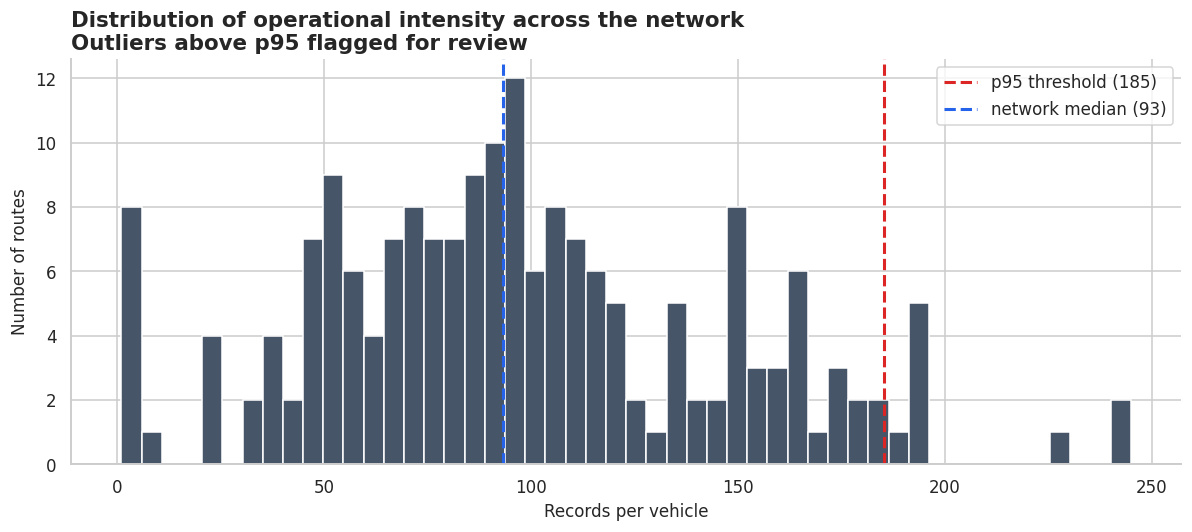

In [19]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(route_counts["records_per_vehicle"], bins=50, color=COLOR_NEUTRAL, edgecolor="white")
ax.axvline(network_p95, color=COLOR_OUTLIER, linestyle="--", linewidth=2,
           label=f"p95 threshold ({network_p95:.0f})")
ax.axvline(network_median, color=COLOR_ACTIVITY, linestyle="--", linewidth=2,
           label=f"network median ({network_median:.0f})")
ax.set_xlabel("Records per vehicle")
ax.set_ylabel("Number of routes")
ax.set_title("Distribution of operational intensity across the network\nOutliers above p95 flagged for review",
             loc="left")
ax.legend()

plt.tight_layout()
save_chart("operational_outliers.png")
plt.show()

### Observation

Two distinct outlier signals show up:

- **Small-fleet, high-record routes** — likely genuine low-frequency or
  community-shuttle routes, but a small number could be data-quality artifacts
  worth verifying against TransLink's published schedule.
- **High-intensity routes above the 95th percentile** — concentrated among
  the established trunk corridors (B-Lines, R-lines, frequent crosstown
  routes). These match expectations and serve as a **healthy-baseline
  fingerprint**: a future run where this list changes significantly is worth
  investigating.

**Operational reading:** the value of this section grows with repeated runs.
With only one observation window, outliers are flagged but not yet
diagnosable. With weekly or daily snapshots, the same outlier-detection
logic becomes a real reliability alarm.

## 11. Executive Summary

**What we measured**

A single ~6-hour afternoon collection window on 2026-05-14, covering 207
TransLink routes, 1,394 distinct vehicles, and several hundred thousand
position reports. All analysis is from the operational metrics layer of the
Transit Reliability Platform.

**What the data shows**

- **Service is concentrated on TransLink's frequent network.** Broadway
  B-Line (099), 49th Avenue (049), R4 41st Avenue, Kingsway (019), and
  Hastings/UBC (014) dominate both telemetry volume and fleet allocation
  during the window. This is the expected shape of TransLink's high-frequency
  corridors.
- **Most routes operated continuously through the window.** ~86% of observed
  routes were active across the full ~6-hour span — consistent with a healthy
  mid-day, mid-week service pattern.
- **Fleet behavior shows operational steady-state.** Across hours 18–23 UTC
  the count of distinct vehicles and routes is stable (~850 vehicles, ~185
  routes). The expected evening-peak signal falls outside the observation
  window.
- **Outlier patterns match expectations.** High-intensity routes are the
  known trunk corridors; small-fleet outliers are limited and warrant
  schedule cross-reference rather than indicating systemic issues.

**What the data cannot yet show**

- Anything related to **vehicle speed or congestion** — the GTFS-RT feed
  publishes `speed = 0` for every record. Speed-based analysis is deferred
  pending either feed improvements or analytical derivation from position
  deltas.
- **Day-of-week or weekly pattern analysis** — the window is partial-day.
- **Schedule conformance** — requires merging realtime telemetry with the
  static GTFS schedule, which is a planned next step.

**Reliability platform readiness**

The pipeline, validation, and metrics layers are working as designed: the
data is clean enough to make confident operational statements about
network-level service concentration, fleet allocation, and route coverage
during the captured window. The next platform investments — longer
collection windows, derived-speed analytics, and schedule conformance —
each unlock a specific class of question that this notebook deliberately
left unanswered.

## 12. Data Limitations and Next Steps

### Documented limitations of this analysis

| Limitation                                 | Impact                                                                                          |
|--------------------------------------------|-------------------------------------------------------------------------------------------------|
| Speed field is 0 across the entire feed    | All speed/congestion analysis blocked until derived-speed is implemented                        |
| ~6-hour single-day observation window      | No weekly trends, no AM-peak data, no weekday-vs-weekend comparison                              |
| No schedule join yet                        | Cannot answer "is service running on time?" or measure schedule conformance                    |
| Stationary metric is a feed-availability proxy, not a movement signal | Until speed is derived, "stationary" should be read as "vehicle reported" |
| No spatial analysis                        | Latitude/longitude exist in raw parquet but are not yet rolled into operational metrics         |

### Prioritized next steps

1. **Extend collection to a full week** so weekday/weekend and AM/PM-peak
   patterns become observable.
2. **Derive speed from position deltas.** Calculate Δdistance / Δtime between
   consecutive reports for each vehicle. This unblocks the originally planned
   congestion and route-speed analyses without depending on TransLink feed
   improvements.
3. **Join realtime telemetry with the static GTFS schedule** (`trips.txt`,
   `stop_times.txt`). This is the precondition for schedule-conformance and
   on-time-performance metrics — the most operationally valuable analytics a
   reliability platform produces.
4. **Add spatial aggregation.** Heatmaps of vehicle density by neighborhood,
   stop-level dwell-time analysis, and route-segment-level slowdown
   detection all become possible once positions are bucketed geographically.
5. **Set up automated weekly reporting.** Re-run this notebook against each
   new week of data, compare top-15 lists and outlier sets against the
   previous week, and alert on material changes.

This notebook is the first read. The next read should answer questions this
one couldn't.